<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/Standard_banner.png' align='right' width='100%'/>

<a href="../Index.ipynb" target="_blank"><< Index</a>
<br>
<a href="./2_4_iono_corr_solarstorms.ipiynb" target="_blank"><< Ionospheric correction solar storms</a>

<font color="#138D75">**Copernicus Marine Training Service**</font> <br>
**Copyright:** 2024 EUMETSAT <br>
**License:** MIT <br>
**Authors:** Ben Loveday (EUMETSAT/Innoflair UG), Hayley Evers-King (EUMETSAT), Vinca Rosmorduc (CLS)

<html>
<div style="float:left"><a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-s6"><img src="https://img.shields.io/badge/open-EUMETLAB-E67E22.svg?style=flat&logo=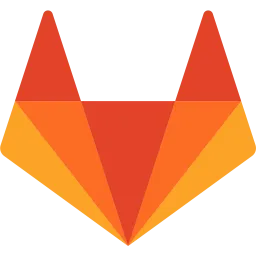" alt="Open in EUMETLAB"></a></div>
    <div style="float:left"><p>&emsp;</p></div>
  </div>
  <div style="width:100%">
    <div style="float:left"><a href="https://user.eumetsat.int/search-view?sort=startDate%20desc&facets=%7B%22contentTypes%22:%5B%22Resources%7CSoftware%20%26%20code%22%5D,%22theme%22:%5B%22Marine%22,%22Marine%7CMaritime%20safety%22,%22Marine%7COcean%20biogeochemistry%22,%22Marine%7COcean%20dynamics%22,%22Marine%7CWater%20quality%22%5D,%22org-satellite-sensor%22:%5B%22EUMETSAT%7CSentinel-6%22,%22EUMETSAT%7CSentinel-6%7CAMR-C%22,%22EUMETSAT%7CSentinel-6%7CDORIS%22,%22EUMETSAT%7CSentinel-6%7CGNSS-RO%22,%22EUMETSAT%7CSentinel-6%7CLRA%22,%22EUMETSAT%7CSentinel-6%7CPoseidon-4%22%5D%7D"><img src="https://img.shields.io/badge/open-USER PORTAL-154360.svg?style=flat&logo=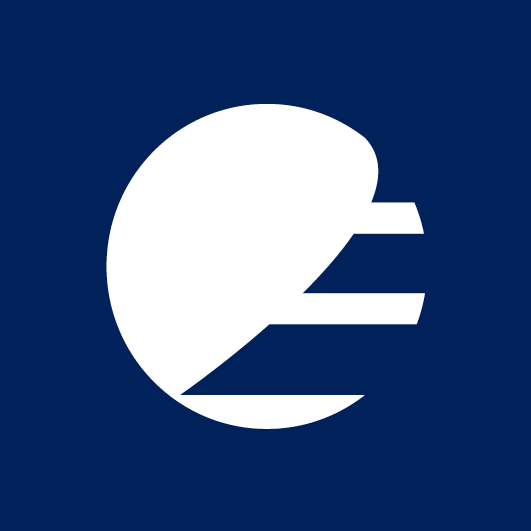" alt="Open in user portal"></a></div>
    <div style="float:left"><p>&emsp;</p></div>
  </div>
  <div style="width:100%">
    <div style="float:left"><a href="https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.eumetsat.int%2Feumetlab%2Foceans%2Focean-training%2Fsensors%2Flearn-s6/HEAD?urlpath=%2Ftree%2F2_S6_advanced%2F2_5_acquire_S6_available_cycles.ipynb"><img src="https://mybinder.org/badge_logo.svg" alt="Launch on Binder"></a></div>
    <div style="float:left"><p>&emsp;</p></div>
  </div>
  <div style="width:100%">
    <div style="float:left"><a href="https://jupyterhub.prod.wekeo2.eu/hub/user-redirect/lab/tree/public/wekeo4oceans/learn-s6/2_S6_advanced/2_5_acquire_S6_available_cycles.ipynb"><img src="https://img.shields.io/badge/launch-WEKEO-1a4696.svg?style=flat&logo=" alt="Launch on WEkEO"></a></div>
    <div style="float:left"><p>&emsp;</p></div>
  </div> 
</html>

<div class="alert alert-block alert-success">
<h3>Learn Sentinel-6: Advanced</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>
    
This notebook has the following prerequisites:
- **<a href="https://eoportal.eumetsat.int/" target="_blank">A EUMETSAT Earth Observation Portal account</a>** to use the EUMETSAT Data Store
    
There are no prerequisite notebooks for this module.
</div>
<hr>

# 2.5 Acquiring a Sentinel-6 track over all available cycles

### Data used

| Product Description  | EUMETSAT Data Store collection ID| EUMETSAT collection<br>description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:--------:|
| Sentinel-6 Poseidon-4 Altimetry level 2 High Resolution  | EO:EUM:DAT:0855 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0855" target="_blank">Description</a> | EO:EUM:DAT:0855| <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3A0855" target="_blank">Description</a> |
| Sentinel-6 Poseidon-4 Altimetry level 2 High Resolution (baseline version F08; reprocessed)  | EO:EUM:DAT:0841 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0841" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-6:0841| <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-6%3A0841" target="_blank">Description</a> |


### Learning outcomes

At the end of this notebook you will know;
* <font color="#138D75">**Search**</font> for a time series of L2 Sentinel-6 data for a given cycle number using the EUMETSAT Data Store API client (`eumdac`)
* <font color="#138D75">**Download**</font> this time series

### Outline

The EUMETSAT Data Store offers many ways to interact with data in order to refine searches. Many of these methods are supported by the EUMETSAT Data Access Client (`eumdac`). In this notebook we will showcase some of the possibilities for using `eumdac` to better interact with Sentinel-6 collections.

In altimetry, a track is the half orbit ground print of the satellite. It is the basic granularity of L2 product files. Sometimes you may need a series of files covering an area (or the entire globe) but, in a number of cases, retrieving a time series of one given track is the best thing to do. It can be useful to compare with an in situ buoy or station, e.g.; or to use data close to a coast.  

Here, we will compare the Gulf Stream front along time where a track (#126) is crossing it, from the beginning of Sentinel-6 up to the most recent "Non-Time Critical" data published (you could try this from the very beginning of Topex/Poseidon, then Jason-1, Jason-2 & Jason-3 - the track number has stayed the same since late 1992, at least while those satellites were on the reference orbit).

<div class="alert alert-info" role="alert">

## <a id='TOC_TOP'></a>Contents

</div>
    
1. [Step 1: Authenticating the API](#section1)
1. [Step 2: list the appropriate products](#section2)
1. [Step 3: Downloading the data](#section3)
1. [Step 4: Using the data](#section4)

<hr>

We begin by importing all of the libraries that we need to run this notebook. If you have built your python using the environment file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="../README.md" target="_blank">README</a>**.

In [1]:
import os                              # a library that allows us access to basic operating system commands
import glob                            # a library that helps us search for files
import json                            # a library that helps us make JSON format files
import eumdac                          # a tool that helps us download via the eumetsat/data-store
import datetime                        # a library that allows us to work with dates and times
import shutil                          # a library that allows us access to basic operating system commands like copy
import zipfile                         # a library that support zipping/unzipping files
import xarray                          # a library that helps us work efficiently with multi-dimensional arrays
import matplotlib                      # a library the provides plotting capability
import matplotlib.pyplot as plt        # a library the provides plotting capability
import cartopy                         # a library that supports mapping and projection
import cartopy.crs as ccrs             # a library that supports mapping and projection
import numpy as np                     # a library that lets us work with arrays; we import this with a new name "np"
from pathlib import Path               # a library that helps construct system path objects

# Create a download directory for our Sentinel-6 products
#download_dir = os.path.join(os.getcwd(), "products")
download_dir = "products/"
os.makedirs(download_dir, exist_ok=True)

# we will look at the North-West Atlantic - Gulf Stream region.
lon_min = -90.; lon_max = -50. ; lat_min = 25. ; lat_max = 42. ;

<div class="alert alert-info" role="alert">

## <a id='section1'></a>Step 1: Authenticating the API
[Back to top](#TOC_TOP)

</div>

Before we use the Data Store to download data, we must first authenticate our access and retrieve an access token. More **essential** information on setting this up can be found in the **<a href="../1_S6_introductory/1_1b_S6_data_access_DS.ipynb">1_1b_S6_data_access_DS</a>** notebook.

In [2]:
# load credentials
file_credentials = True

if file_credentials == True:
    credentials_file = os.path.join(os.path.expanduser("~"),'.eumdac','credentials')
    credentials = Path(credentials_file).read_text().split(',')
    token = eumdac.AccessToken((credentials[0], credentials[1]))
    print(f"This token '{token}' expires {token.expiration}")
else:
    # see below for more information
    token = eumdac.AccessToken(("consumer_key", "consumer_secret"))

This token 'fb059e8b-87ff-392b-81bc-0fadeca1261d' expires 2024-12-17 14:05:04.576560


In [3]:
datastore = eumdac.DataStore(token)

<div class="alert alert-info" role="alert">

## <a id='section2'></a>Step 2: list the appropriate collections
[Back to top](#TOC_TOP)

</div>

We will take the Level 2 high resolution data for the whole availability of these data from Sentinel-6, whether the data are reprocessed or operational.
Now, we have several version of the Level-2 reprocessed data in the catalogue. Except for very specific studies, you should take the latest version - it should be the one the most homogeneous with the operational version.

In [4]:
# list the relevant Sentinel-6 collection IDs and store them in a list to access them. The lowest version number currently available is F06, 
# we will start from this number, to compare it with the one(s) in the collections' names, to take the highest (note that the list of collection is
# not ordered chronologically nor alphabetically.  Note that the version number position in the title will change with the product name, 
# but will be after F. 

target_collection = "Poseidon-4 Altimetry Level 2 High Resolution"
version_number = 6
list_colIDs = []
for collection_id in datastore.collections:
    if (target_collection in collection_id.title):
        # for reprocessed collection, the "baseline" (i.e. the version) is provided in the title. 
        # We are searching for the highest of these version numbers (on two characters - 06, 08, 09, 10 ... , with a letter for 
        # the "standards" applied before - F, G... , but the version number increasing independently of it )
        if ("baseline version" in collection_id.title):
            vnum_start = collection_id.title.find('baseline version ')+len('baseline version ') + 1
            if version_number < int(collection_id.title[vnum_start:vnum_start+2]):
                version_number = int(collection_id.title[vnum_start:vnum_start+2])
                highest_version_ID = collection_id
        else:
            list_colIDs.append(str(collection_id))
            if "non-public" in collection_id.abstract: continue

list_colIDs.append(str(highest_version_ID))

print(list_colIDs)

['EO:EUM:DAT:0855', 'EO:EUM:DAT:0841']


<div class="alert alert-info" role="alert">

## <a id='section3'></a>Step 3: Downloading the products
[Back to top](#TOC_TOP)

</div>

In [5]:
# set collection ID for S6 Poseidon-4 L2 high resolution products
#collectionID = 'EO:EUM:DAT:0842'
relorbit = '63'
#direction = 'DESCENDING' ##not currently correct
timeliness = 'NT'
for collectionID in list_colIDs:
    selected_collection = datastore.get_collection(collectionID)
    products = selected_collection.search(
        relorbit=relorbit,
#        orbitdir=direction,
        timeliness=timeliness)

    for product in products:
    # we are interested in relative orbit 063 *_descending_* track, i.e. track 126 when numbering by half orbits. This number not part of the metadata
    # but it is in the product names. We will take only the reduced files - again using the product name. 
        for entry in product.entries:
            if all(x in entry for x in ['S6A_P4_2__HR_RED_', '_126_063_EUM_']):
                with product.open(entry=entry) as fsrc, open(os.path.join(os.getcwd(), download_dir, fsrc.name), mode='wb') as fdst:
                    shutil.copyfileobj(fsrc, fdst)
                    print(f'Download of file {fsrc.name} finished.')
                    

Download of file S6A_P4_2__HR_RED__NT_148_126_20241119T034130_20241119T043743_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_147_126_20241109T054259_20241109T063912_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_146_126_20241030T074427_20241030T084040_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_145_126_20241020T094556_20241020T104208_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_144_126_20241010T114723_20241010T124336_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_143_126_20240930T134851_20240930T144504_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_142_126_20240920T155018_20240920T164631_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_141_126_20240910T175147_20240910T184800_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_140_126_20240831T195316_20240831T204929_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_139_126_20240821T215445_20240821T225058_F09.nc finished.
Download of file S6A_P4_2__HR_RED__NT_138_126_2024

<div class="alert alert-info" role="alert">

## <a id='section4'></a>Step 4: Using the products
[Back to top](#TOC_TOP)

</div>

The selected track is one of those crossing the Gulf Stream front. We will just plot the Absolute Dynamic Topography (to have the topography due to the mean currents in the sea surface height data) from one of the downloaded files, first on a map - to locate the track we're using - then with respect to latitude and only latitude, to better see the amplitude and shape of the variations.

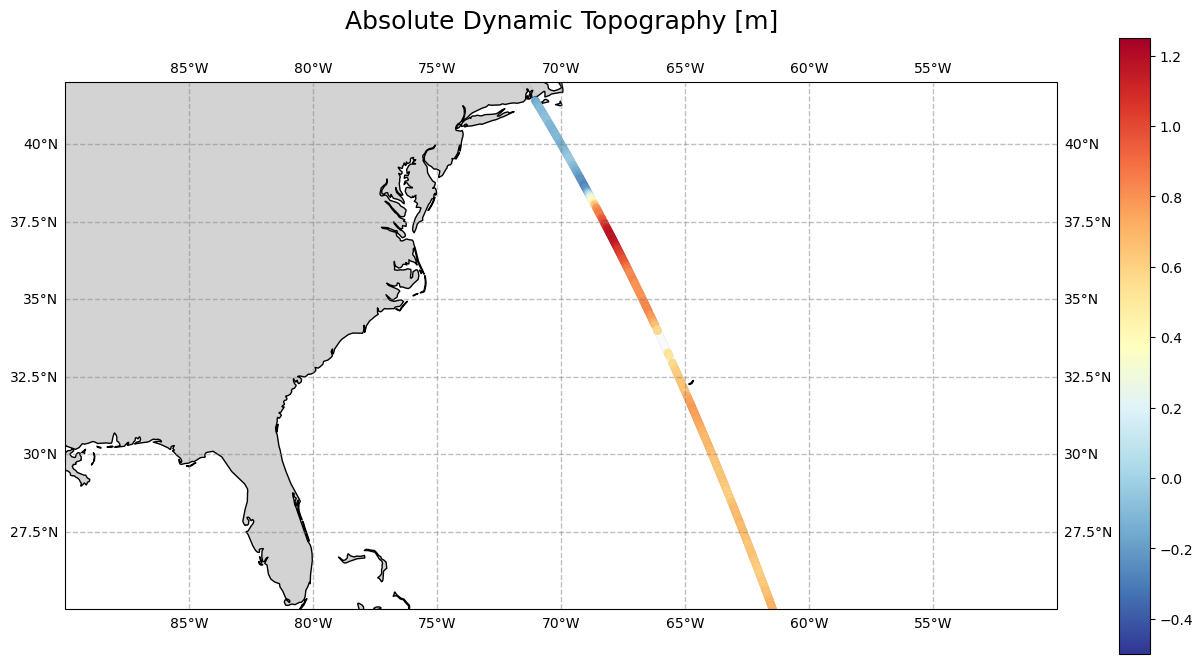

In [6]:
input_file = 'S6A_P4_2__HR_RED__NT_046_126_20220211T181147_20220211T190800_F08.nc'
my_file = os.path.join(download_dir,input_file)
nc01 = xarray.open_dataset(my_file, group='data_01')
nc01ku = xarray.open_dataset(my_file, group='data_01/ku')

lat = nc01['latitude']
lon = nc01['longitude']
time = nc01['time']
ssha = nc01ku['ssha']
mdt = nc01['mean_dynamic_topography']

flags_ssha = nc01.surface_classification_flag + nc01ku.range_ocean_qual + nc01ku.sig0_ocean_qual + nc01.rain_flag + nc01ku.swh_ocean_qual \
        + nc01.meteo_map_availability_flag + nc01.mean_dynamic_topography_qual + nc01.mean_sea_surface_sol1_qual + nc01.rad_sea_ice_flag \
        + nc01.rad_wet_tropo_cor_qual

ssha[flags_ssha != 0.0] = np.nan

adt = ssha + mdt

fig = plt.figure(figsize=(16,8))
ax = plt.axes(projection=ccrs.PlateCarree(), aspect=1.25)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=1)
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
# actually plot the data
tracks = ax.scatter(lon, lat, c=adt,  vmin=-0.5, vmax=1.25, cmap='RdYlBu_r', marker='o', edgecolors='black', linewidth=0.01)
cbar = plt.colorbar(tracks)
plt.title('Absolute Dynamic Topography [m]', size=18, pad=24)
plt.savefig("adt_gulfstream.png", bbox_inches="tight")
plt.show()

To get a better view of the "front", a ADT vs latitude (or time) can be clearer. You then see a sharp change, of about 1 m in about 1°-2° in latitude.

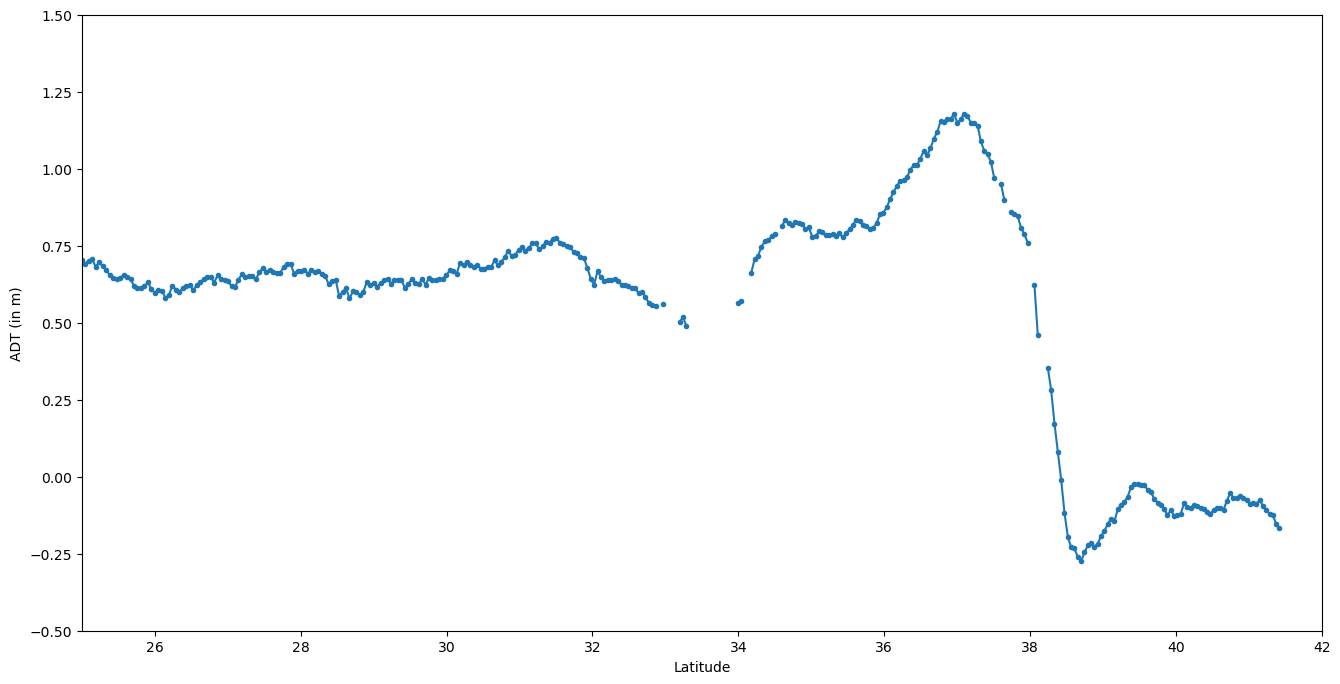

In [7]:
fig = plt.figure(figsize=(16,8))
plt.ylabel('ADT (in m)')
plt.xlabel('Latitude')
plt.plot(lat, adt, marker=".")
# we plot only over the 30-40°N part, where we have the current front (sharp SSH difference above). 
plt.axis([lat_min, lat_max, -0.5, 1.5])
plt.savefig("adt_along-track_gulfstream.png", bbox_inches="tight")

Now, we will use all our files for this given track, grouped different ways. First we create a new file with all the tracks, only the variables we're interested in and only over the lat_min - lat_max area. 

In [8]:
s6_files = glob.glob(os.path.join(download_dir,'S6A_P4_2__HR_RED_*.nc'))
# we sort the files - by default it is "alphabetical" order, but pass numbers are also correctly ordered, which provide with a time-ordered list
# this sorting will provide with a well-orderer dataset/nc file. 
s6_files.sort()

if s6_files != []:
   #we will use variables which are all in the data_01 group, so this is the only one we're opening
    s6data01 = xarray.open_mfdataset(s6_files, group='data_01', combine='nested', concat_dim='time', compat='no_conflicts')
    s6data01ku = xarray.open_mfdataset(s6_files, group='data_01/ku', combine='nested', concat_dim='time', compat='no_conflicts')

lat = s6data01['latitude']
lon = s6data01['longitude']
time = s6data01['time']
ssha = s6data01ku['ssha']
mdt = s6data01['mean_dynamic_topography']

flags_ssha = s6data01.surface_classification_flag + s6data01ku.range_ocean_qual + s6data01ku.sig0_ocean_qual + s6data01ku.swh_ocean_qual \
             + s6data01.rain_flag + s6data01.meteo_map_availability_flag + s6data01.mean_dynamic_topography_qual + s6data01.mean_sea_surface_sol1_qual \
             + s6data01.rad_sea_ice_flag + s6data01.rad_wet_tropo_cor_qual

adt = ssha + mdt


The variables come from two groups, and thus we have two different datasets. For easiness of use, we'll created a unique dataset with the interesting variables (for this case study). 

In [9]:
#creating a proper dataset with attributes for a nc files 
ds = xarray.Dataset(
    {'adt01': (['time'],  \
                adt.data, \
                {'standard_name' : 'sea_surface_height_above_geoid', \
                 'units' : "m", \
                 'coordinates' : "longitude latitude"}),
    'flags_ssha01': (['time'],  \
                flags_ssha.data, \
                {'standard_name' : 'editing flag', \
                 'coordinates' : "longitude latitude"})
    }, 
    coords={
        'time': (['time'], \
                 time.data, \
                 {'standard_name' : 'time', \
                  #'units' : "seconds since 2000-01-01 00:00:00.0", \ # a unit is kept in the concatenation by this dimension
                  'coordinates' : "longitude latitude"}),
        'lon01': (['time'], lon.data, \
                {'standard_name' : 'longitude', \
                 'units' : "degrees_east", \
                 'coordinates' : "longitude latitude"}), 
        'lat01': (['time'], lat.data, \
                  {'standard_name' : 'latitude', \
                   'units' : "degrees_north", \
                   'coordinates' : "longitude latitude"})
            })

# keep only the part between lat_min & lat_max
gs_ds = ds.sel(time=((ds.lat01 > lat_min) & (ds.lat01 < lat_max)))
# save the file for future use
gs_ds.to_netcdf('adt_gs_tr126_S6.nc')

ds.close()
s6data01.close()
s6data01ku.close()
gs_ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 52366)
Coordinates:
  * time          (time) datetime64[ns] 419kB 2020-12-22T07:27:12 ... 2024-11...
    lon01         (time) float64 419kB dask.array<chunksize=(3219,), meta=np.ndarray>
    lat01         (time) float64 419kB dask.array<chunksize=(3219,), meta=np.ndarray>
Data variables:
    adt01         (time) float64 419kB dask.array<chunksize=(3219,), meta=np.ndarray>
    flags_ssha01  (time) float32 209kB dask.array<chunksize=(3219,), meta=np.ndarray>

Now we'll plot a few graphs per month, season or year. For this, we will make use of "groupby", which can accomodate a number of time subdivisions. We also need to harmonize the latitudes before averaging, since they are slightly different from one cycle to the other: the ground track is kept with a precision of +/1 km, which means that latitudes (nor longitudes) are never exactly the same within L2 products (NB. L3 are projected unto a "theoretical" track, thus for those products the latitudes and longitudes for a same track are identical whatever the date/cycle)

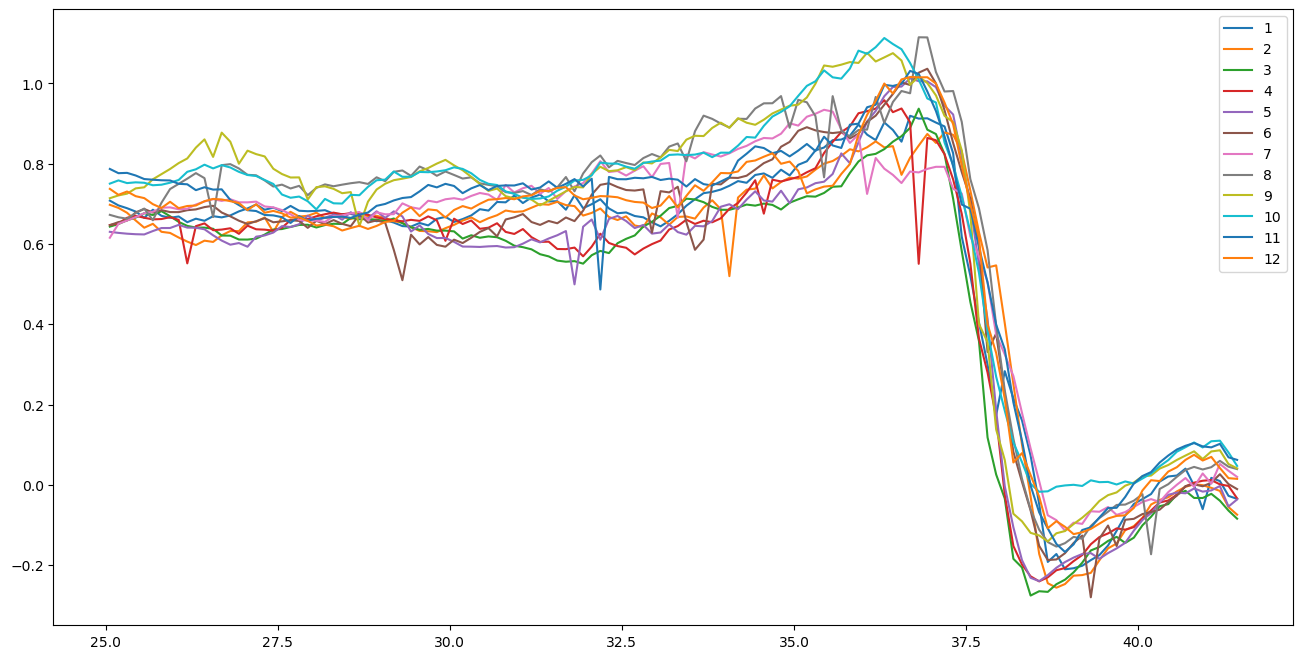

In [10]:
# NB. native difference between two latitudes is of the order of 0.065° (~1/15°); 
# using a longer distance smooths the turbulent features and enable to better see the large-scale information
lat_bin = 0.125

fig = plt.figure(figsize=(16,8))    
for month_id, ds_month in gs_ds.groupby('time.month'):
    permonth = ds_month.where(ds_month.flags_ssha01==0)
    lat_bins_list = np.arange(lat_min, lat_max, lat_bin)
    lat_bin_labels = np.arange(lat_min+(lat_bin/2), lat_max-(lat_bin/2), lat_bin)
    averaged_data = permonth.groupby_bins('lat01', lat_bins_list, labels=lat_bin_labels).mean()
    plt.plot(lat_bin_labels, averaged_data.adt01, label=month_id)
    plt.legend()
plt.savefig("track126_monthly.png", bbox_inches="tight")

Here we see higher values of ADT for 'summer' months (water being warmer, sea surface height is higher) than "winter". March & April are lowest, August & September highest. The slope is not exactly at the same latitude depending on the months, but there are a bit too many curves to clearly see. Switching to "seasons" may enable to get a better view.  

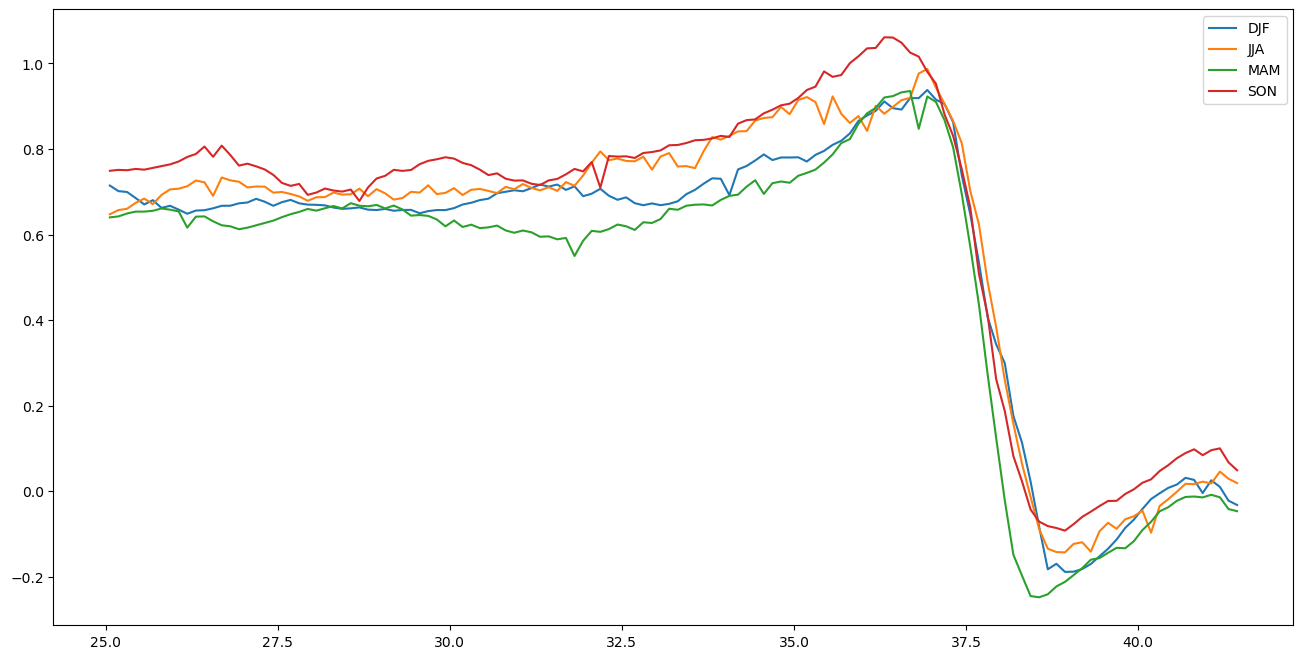

In [11]:
fig = plt.figure(figsize=(16,8))    

for season_id, ds_season in gs_ds.groupby('time.season'):
    perseason = ds_season.where(ds_season.flags_ssha01==0)
    lat_bins_list = np.arange(lat_min, lat_max, lat_bin)
    lat_bin_labels = np.arange(lat_min+(lat_bin/2), lat_max-(lat_bin/2), lat_bin)
    averaged_data = perseason.groupby_bins('lat01', lat_bins_list, labels=lat_bin_labels).mean()
    plt.plot(lat_bin_labels, averaged_data.adt01, label=season_id)
    plt.legend()
plt.savefig("track126_seasonally.png", bbox_inches="tight")

Above, we see that Sept-Oct-Nov ADT are higher than "(ocean) winter" (March-April-May), again in link with the water temperature. Spring slope seems to be slightly shifted towards the south, but this would need a longer time series than S6 data availability to assess.

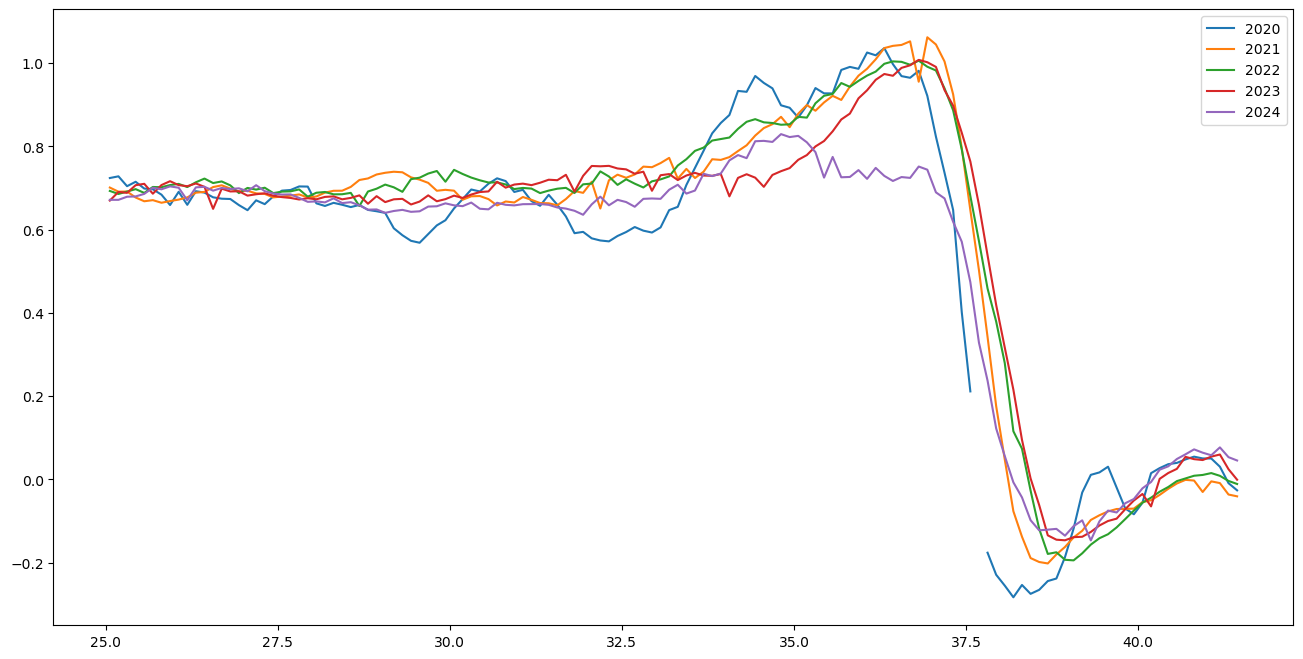

In [12]:
fig = plt.figure(figsize=(16,8))    

for year_id, ds_year in gs_ds.groupby('time.year'):
    peryear = ds_year.where(ds_year.flags_ssha01==0)
    lat_bins_list = np.arange(lat_min, lat_max, lat_bin)
    lat_bin_labels = np.arange(lat_min+(lat_bin/2), lat_max-(lat_bin/2), lat_bin)
    averaged_data = peryear.groupby_bins('lat01', lat_bins_list, labels=lat_bin_labels).mean()
    plt.plot(lat_bin_labels, averaged_data.adt01, label=year_id)
    plt.legend()
plt.savefig("track126_yearly.png", bbox_inches="tight")

2020 and 2024 are not complete (at the day of writing for 2024; 2020 will never be, due to Sentinel-6 launch date), so the differences in the slope position for those two years are not conclusive. 
Studies show that the Gulf Stream front is oscillating at interannual time-scales, but a longer time-series would be needed (see e.g.;  Guo, Y., Bishop, S., Bryan, F., & Bachman, S. (2023). Mesoscale variability linked to interannual displacement of Gulf Stream. Geophysical Research Letters, 50, e2022GL102549. https://doi.org/10.1029/2022GL102549 .
Long-term trend of the position is yet unclear (see e.g.;  Chi, L., Wolfe, C. L. P., & Hameed, S. (2021). Has the Gulf Stream slowed or shifted in the altimetry era? Geophysical Research Letters, 48, e2021GL093113. https://doi.org/10.1029/2021GL093113 )

<hr>
<a href="../Index.ipynb" target="_blank"><< Index</a>
<br>
<a href="./2_4_iono_corr_solarstorms.ipiynb" target="_blank"><< Ionospheric correction solar storms</a>
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/ocean">View on GitLab</a> | <a href="https://training.eumetsat.int/">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int>Contact helpdesk for support </a> | <a href=mailto:training@eumetsat.int>Contact our training team to collaborate on and reuse this material</a></span></p>